# 13 - Patient-level dataset (Approach 2)
Reshape visit data (406k rows) into one row per patient (180k).
Target: how soon each patient returns - 4 buckets plus raw days.
Feeds XGBoost (nb14) and LSTM (nb15). Full rationale: `docs/notebook_design_notes.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Absolute paths to the local repo, so this runs without editing.
# (For Colab instead, change these to where you upload the CSVs.)
DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
OUT_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/13_patient_dataset"

SEED = 42
np.random.seed(SEED)

In [2]:
# Rebuild the full population. The clean files were already split by visit for
# the old approach; we concat them back together and re-split by patient later.
train = pd.read_csv(f"{DATA_DIR}/train_data_clean.csv")
test = pd.read_csv(f"{DATA_DIR}/test_data_clean.csv")
df = pd.concat([train, test], ignore_index=True)

print(f"admissions: {len(df):,}")
print(f"unique patients: {df['subject_id'].nunique():,}")

admissions: 406,031
unique patients: 180,352


## Target
Sort each patient's visits by date; gap from discharge to their next admission.
Buckets at 30/60/90 days; no next admission means never returned.

In [3]:
df["admittime"] = pd.to_datetime(df["admittime"])
df["dischtime"] = pd.to_datetime(df["dischtime"])
df = df.sort_values(["subject_id", "admittime"]).reset_index(drop=True)

# The next admission for the same patient (NaT if this was their last one).
df["next_admit"] = df.groupby("subject_id")["admittime"].shift(-1)
df["days_to_next"] = (df["next_admit"] - df["dischtime"]).dt.total_seconds() / 86400

# A handful of records have a next admission starting before the current one is
# discharged (overlapping/erroneous dates). Too few to matter, so we drop them.
overlap = df["days_to_next"] < 0
print(f"dropping {overlap.sum()} overlapping-date rows")
df = df[~overlap].reset_index(drop=True)

dropping 23 overlapping-date rows


In [4]:
def to_bucket(days):
    if pd.isna(days):
        return "never"
    if days < 30:
        return "lt30"
    if days < 60:
        return "30_60"
    if days <= 90:
        return "60_90"
    return "gt90"

df["tgt_bucket"] = df["days_to_next"].apply(to_bucket)
df["tgt_days"] = df["days_to_next"]  # raw days, NaN = never (for the regression model)

# Visit number within each patient - needed for the sequence model and for
# picking out the first visit below.
df["visit_num"] = df.groupby("subject_id").cumcount() + 1

print(df["tgt_bucket"].value_counts())

tgt_bucket
never    180352
gt90     114780
lt30      70181
30_60     25557
60_90     15138
Name: count, dtype: int64


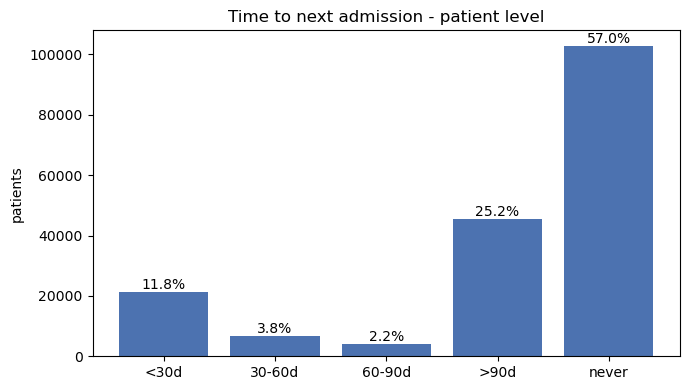

In [5]:
# Graph: target balance at patient level (visualises the buckets printed above).
fv = df[df["visit_num"] == 1]
order = ["lt30", "30_60", "60_90", "gt90", "never"]
labels = ["<30d", "30-60d", "60-90d", ">90d", "never"]
counts = fv["tgt_bucket"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, counts.values, color="#4c72b0")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v/len(fv)*100:.1f}%", ha="center", va="bottom")
ax.set_title("Time to next admission - patient level")
ax.set_ylabel("patients")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/13_target_buckets.png", dpi=150)
plt.show()

## Output tables
Sequence table keeps all visits (LSTM); first-visit table keeps one row per patient (XGBoost).
Leakage columns dropped: timestamps, target helpers, old `readmitted_30/60/90` flags.

In [6]:
leak_cols = [
    "admittime", "dischtime", "next_admit", "days_to_next",
    "readmitted_30d", "readmitted_60d", "readmitted_90d",
]

sequences = df.drop(columns=leak_cols)
first_visit = sequences[sequences["visit_num"] == 1].copy()

print(f"sequence rows (all visits): {len(sequences):,}")
print(f"first-visit rows (one per patient): {len(first_visit):,}")
print()
print("first-visit target distribution:")
print(first_visit["tgt_bucket"].value_counts(normalize=True).round(3))

sequence rows (all visits): 406,008
first-visit rows (one per patient): 180,352

first-visit target distribution:
tgt_bucket
never    0.570
gt90     0.252
lt30     0.118
30_60    0.038
60_90    0.022
Name: proportion, dtype: float64


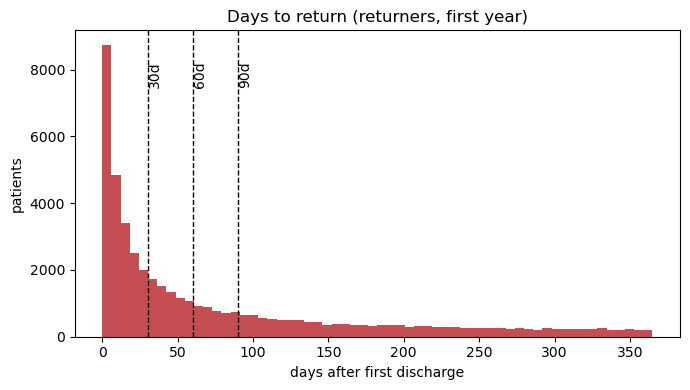

In [7]:
# Graph: when do returners come back? (deepens the target distribution above)
returned = df.loc[df["visit_num"] == 1, "tgt_days"].dropna()
returned = returned[returned <= 365]  # zoom into the first year

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(returned, bins=60, color="#c44e52")
for d in (30, 60, 90):
    ax.axvline(d, color="black", linestyle="--", linewidth=1)
    ax.text(d, ax.get_ylim()[1]*0.9, f"{d}d", rotation=90, va="top")
ax.set_title("Days to return (returners, first year)")
ax.set_xlabel("days after first discharge")
ax.set_ylabel("patients")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/13_days_to_return.png", dpi=150)
plt.show()

## Patient-level split
Split on `subject_id`, not rows, so no patient is in both train and test.
80/20; every row tagged with its split.

In [8]:
patients = df["subject_id"].unique()
shuffled = np.random.permutation(patients)
cut = int(len(shuffled) * 0.8)
train_ids = set(shuffled[:cut])

for tbl in (sequences, first_visit):
    tbl["split"] = np.where(tbl["subject_id"].isin(train_ids), "train", "test")

print(first_visit["split"].value_counts())
print()
# Confirm no patient leaks across the split.
overlap_ids = set(first_visit.loc[first_visit.split == "train", "subject_id"]) \
    & set(first_visit.loc[first_visit.split == "test", "subject_id"])
print(f"patients in both splits (must be 0): {len(overlap_ids)}")

split
train    144281
test      36071
Name: count, dtype: int64

patients in both splits (must be 0): 0


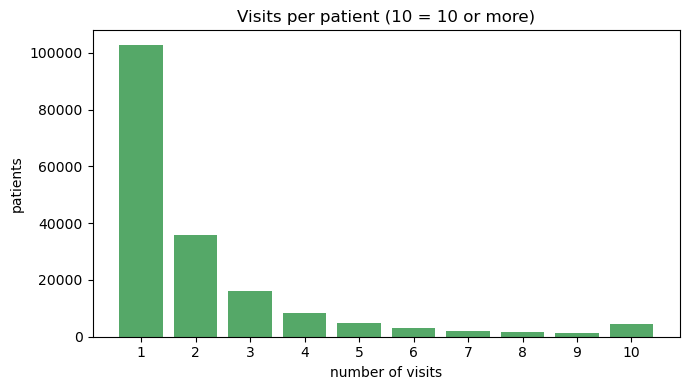

In [9]:
# Graph: visits per patient. The long tail is the frequent flyers; 57% have one.
visits = df.groupby("subject_id").size()
vc = visits.clip(upper=10).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index.astype(str), vc.values, color="#55a868")
ax.set_title("Visits per patient (10 = 10 or more)")
ax.set_xlabel("number of visits")
ax.set_ylabel("patients")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/13_visits_per_patient.png", dpi=150)
plt.show()

In [10]:
first_visit.to_csv(f"{OUT_DIR}/patient_first_visit.csv", index=False)
sequences.to_csv(f"{OUT_DIR}/patient_sequences.csv", index=False)
print("saved patient_first_visit.csv and patient_sequences.csv")

saved patient_first_visit.csv and patient_sequences.csv
